## Predict whether a caner cell line is sensitive or resistant to treatments using LN_IC50
### Step1: Import and Load Libraries

In [1]:
#pip install xgboost

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc, f1_score

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


In [2]:
read_path= 'https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx'

In [3]:
df_gdsc = pd.read_excel(read_path)

In [4]:
df_gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


### Decide Modeling Scope - One or many drugs?

In [5]:
df_gdsc['DRUG_NAME'].nunique()

246

In [6]:
df_gdsc['DRUG_NAME'].value_counts()

DRUG_NAME
Ulixertinib       1302
Oxaliplatin       1287
Fulvestrant       1283
Selumetinib       1273
Dactinomycin      1264
                  ... 
CCT-018159         159
Piperlongumine     159
Bicalutamide       159
IOX2               159
CHIR-99021         159
Name: count, Length: 246, dtype: int64

In [7]:
df_gdsc['DRUG_NAME'].value_counts()['Camptothecin']

np.int64(736)

#### I will be using Oxaliplatin cos it has higher sample size and something biologically interesting about it (mechanism of action, why sensitivity might vary by tissue)

In [8]:
DRUG_OF_INTEREST = "Oxaliplatin"   # <-- change to the drug you want to model

df_drug = df_gdsc[df_gdsc['DRUG_NAME'] == DRUG_OF_INTEREST].copy()
print(df_drug.shape)
df_drug.head()

(1287, 19)


,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
41957,683667,PFSK-1,MB,1089,Oxaliplatin,3.228135,0.934275,-0.333471,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication
41958,687448,COLO-829,SKCM,1089,Oxaliplatin,7.509457,0.978158,2.138213,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication
41959,687455,RT4,BLCA,1089,Oxaliplatin,2.776521,0.905836,-0.594196,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication
41960,687457,SW780,BLCA,1089,Oxaliplatin,3.729395,0.931042,-0.044084,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication
41961,687459,TCCSUP,BLCA,1089,Oxaliplatin,5.566915,0.974440,1.016749,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication


### Step2: Inspect Dataset

In [9]:
df_drug.info()

<class 'pandas.DataFrame'>
Index: 1287 entries, 41957 to 108791
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   COSMIC_ID                                1287 non-null   int64  
 1   CELL_LINE_NAME                           1287 non-null   str    
 2   TCGA_DESC                                1287 non-null   str    
 3   DRUG_ID                                  1287 non-null   int64  
 4   DRUG_NAME                                1287 non-null   str    
 5   LN_IC50                                  1287 non-null   float64
 6   AUC                                      1287 non-null   float64
 7   Z_SCORE                                  1287 non-null   float64
 8   GDSC Tissue descriptor 1                 1287 non-null   str    
 9   GDSC Tissue descriptor 2                 1287 non-null   str    
 10  Cancer Type (matching TCGA label)        1287 non-null   s

In [10]:
df_drug.describe()

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE
count,1.287000e+03,1287.000000,1287.000000,1287.000000,1287.000000
mean,9.855045e+05,1395.967366,4.372544,0.930089,0.049821
std,2.242727e+05,354.914796,1.740211,0.064159,0.973749
min,6.836670e+05,1089.000000,-0.867912,0.538205,-2.709563
25%,9.059770e+05,1089.000000,3.118335,0.907907,-0.590807
50%,9.092510e+05,1089.000000,4.414730,0.952732,0.085959
75%,1.240142e+06,1806.000000,5.749945,0.973361,0.743812
max,1.674021e+06,1806.000000,9.402103,0.996289,2.895406


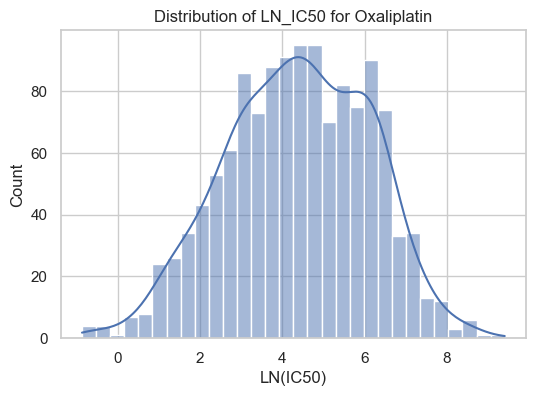

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df_drug['LN_IC50'], kde=True, bins=30)
plt.title(f"Distribution of LN_IC50 for Oxaliplatin")
plt.xlabel("LN(IC50)")
plt.show()

In [38]:
df_drug['LN_IC50'].describe()

count    1287.000000
mean        4.372544
std         1.740211
min        -0.867912
25%         3.118335
50%         4.414730
75%         5.749945
max         9.402103
Name: LN_IC50, dtype: float64

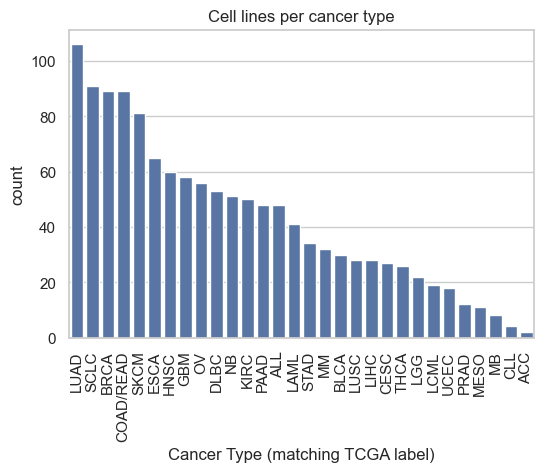

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_drug, x='Cancer Type (matching TCGA label)',
              order=df_drug['Cancer Type (matching TCGA label)'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Cell lines per cancer type")
plt.show()

In [40]:
df_drug.isna().sum()

COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
dtype: int64

### Drop columns that would leak answers or add no value
- `AUC` and `Z_SCORE` are **other measures of the same drug response** as `LN_IC50` — using them as
  predictors would be data leakage (the model would just be learning a near-perfect algebraic
  relationship, not biology).
- `COSMIC_ID` are identifiers, not biological features.
- `DRUG_ID` / `DRUG_NAME` are constant once we've filtered to one drug, so they carry no information
  (drop them here; keep them if you went with Option B above).
- `CNA`, `Gene Expression`, `Methylation` columns in this file are just Y/N flags for *data
  availability*, not the actual omics values, so they add very little signal — keep them if you like,
  but don't expect much from them.

In [42]:
leak_cols = ['AUC', 'Z_SCORE']
id_cols = ['COSMIC_ID', 'DRUG_ID', 'DRUG_NAME']

df_model = df_drug.drop(columns=leak_cols + id_cols, errors='ignore')
df_model.head()

,CELL_LINE_NAME,TCGA_DESC,LN_IC50,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
41957,PFSK-1,MB,3.228135,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication
41958,COLO-829,SKCM,7.509457,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication
41959,RT4,BLCA,2.776521,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication
41960,SW780,BLCA,3.729395,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication
41961,TCCSUP,BLCA,5.566915,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication


### Step3: Create Classification Target Variable

Anything **below the 25th percentile** of `LN_IC50` = **sensitive** (low IC50 = drug works at low dose).
Anything **above the 75th percentile** = **resistant**. Everything in between is discarded (it's
ambiguous / intermediate response).

sensitive = 1
resistnace = 0

In [43]:
lower = df_model["LN_IC50"].quantile(0.25)   # 0.25 can be adjusted between 0 and 1
upper = df_model["LN_IC50"].quantile(0.75)   # 0.75 can be adjusted between 0 and 1

print(f"Lower (25th pct): {lower:.3f}")
print(f"Upper (75th pct): {upper:.3f}")

Lower (25th pct): 3.118
Upper (75th pct): 5.750


In [120]:
def label_sensitivity(x):
    if x <= lower:
        return 1
    elif x >= upper:
        return 0
    else:
        return None

df_model["sensitivity"] = df_model["LN_IC50"].apply(label_sensitivity)

df_class = df_model[df_model["sensitivity"].notna()].copy()
df_class["sensitivity"] = df_class["sensitivity"].astype(int)   # belt and braces
print(df_class["sensitivity"].value_counts())

sensitivity
0    322
1    322
Name: count, dtype: int64


In [121]:
df_class.head()

,CELL_LINE_NAME,TCGA_DESC,LN_IC50,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY,sensitivity
41958,COLO-829,SKCM,7.509457,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication,0
41959,RT4,BLCA,2.776521,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication,1
41964,ME-180,CESC,2.782148,urogenital_system,cervix,CESC,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication,1
41966,8-MG-BA,GBM,3.002351,nervous_system,glioma,GBM,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication,1
41967,A172,GBM,2.265004,nervous_system,glioma,GBM,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,DNA alkylating agent,DNA replication,1


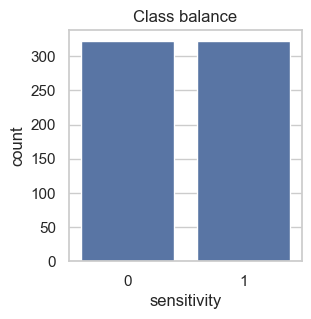

In [122]:
plt.figure(figsize=(3,3))
sns.countplot(data=df_class, x='sensitivity')
plt.title("Class balance")
plt.show()

### Encode Categorical Labels

In [123]:
cat_cols = [
    'CELL_LINE_NAME',
    'TCGA_DESC',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
    'Cancer Type (matching TCGA label)',
    'Microsatellite instability Status (MSI)',
    'Screen Medium',
    'Growth Properties',
    'TARGET',
    'TARGET_PATHWAY',
    'CNA',
    'Gene Expression',
    'Methylation'
]



In [124]:
cat_cols = [c for c in cat_cols if c in df_model.columns]

# lower-case text columns to avoid duplicate categories from inconsistent casing
for col in cat_cols:
    df_class[col] = df_class[col].astype(str).str.strip().str.lower()

print(cat_cols)

['CELL_LINE_NAME', 'TCGA_DESC', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'TARGET', 'TARGET_PATHWAY', 'CNA', 'Gene Expression', 'Methylation']


In [125]:
df_encoded = pd.get_dummies(df_class, columns=cat_cols, drop_first=True, dtype=int)
print(df_encoded.shape)
df_encoded.head()

(644, 594)


,LN_IC50,sensitivity,CELL_LINE_NAME_639-v,CELL_LINE_NAME_647-v,CELL_LINE_NAME_769-p,CELL_LINE_NAME_786-0,CELL_LINE_NAME_8-mg-ba,CELL_LINE_NAME_8305c,CELL_LINE_NAME_8505c,CELL_LINE_NAME_a101d,...,Cancer Type (matching TCGA label)_stad,Cancer Type (matching TCGA label)_thca,Cancer Type (matching TCGA label)_ucec,Microsatellite instability Status (MSI)_mss/msi-l,Screen Medium_r,Growth Properties_semi-adherent,Growth Properties_suspension,CNA_y,Gene Expression_y,Methylation_y
41958,7.509457,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,1,1,1
41959,2.776521,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1,1
41964,2.782148,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1,1
41966,3.002351,1,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,1,1
41967,2.265004,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1,1


### Step 4: Split Features and Labels (Resistant and Sensitive)

In [126]:
drop_cols = ["LN_IC50", "sensitivity"]

X = df_encoded.drop(columns=drop_cols)
y = df_class["sensitivity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (644, 592)
y shape: (644,)


In [127]:
print("X shape:", X.shape)
print("Classes:", sorted(y.unique()))

X shape: (644, 592)
Classes: [np.int64(0), np.int64(1)]


### Step 5: Train/Test Split

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [129]:
X_train.shape

(450, 592)

In [130]:
X_test.shape

(194, 592)

In [131]:
y_train.head

<bound method NDFrame.head of 108585    0
42515     0
42380     1
108652    0
42530     1
         ..
108356    0
42252     1
42625     1
108300    0
42376     1
Name: sensitivity, Length: 450, dtype: int64>

In [132]:
y_test.head

<bound method NDFrame.head of 108358    0
42614     1
42036     1
108299    0
108537    0
         ..
108468    0
108770    0
108704    0
42503     0
42391     1
Name: sensitivity, Length: 194, dtype: int64>

### Step 7: Scale the Dataset (Numeric Features)
This is important because of the variability of the encoded numbers across each columns.

In [133]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [134]:
X_train_scaled.shape

(450, 592)

In [135]:
X_test_scaled.shape

(194, 592)

### Step 8: Classification Models Random Forest and XG Boost  
#### Random Forest

In [136]:
from sklearn.ensemble import RandomForestClassifier

rfm = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rfm.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

#### Predict Random Forest Model

In [137]:
rfm_pred = rfm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, rfm_pred))
print(classification_report(y_test, rfm_pred)) 

Accuracy: 0.8247422680412371
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        97
           1       0.89      0.74      0.81        97

    accuracy                           0.82       194
   macro avg       0.83      0.82      0.82       194
weighted avg       0.83      0.82      0.82       194



#### XG Boost

In [138]:
xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_clf.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

#### Predict XG Boost Model

In [144]:
xgb_pred = xgb_clf.predict(X_test_scaled)

print("XGBoost — Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, target_names=['sensitive', 'resistant']))

XGBoost — Accuracy: 0.7680412371134021
              precision    recall  f1-score   support

   sensitive       0.74      0.84      0.78        97
   resistant       0.81      0.70      0.75        97

    accuracy                           0.77       194
   macro avg       0.77      0.77      0.77       194
weighted avg       0.77      0.77      0.77       194



### Step 10: Confusion Matrices

#### Random Forest

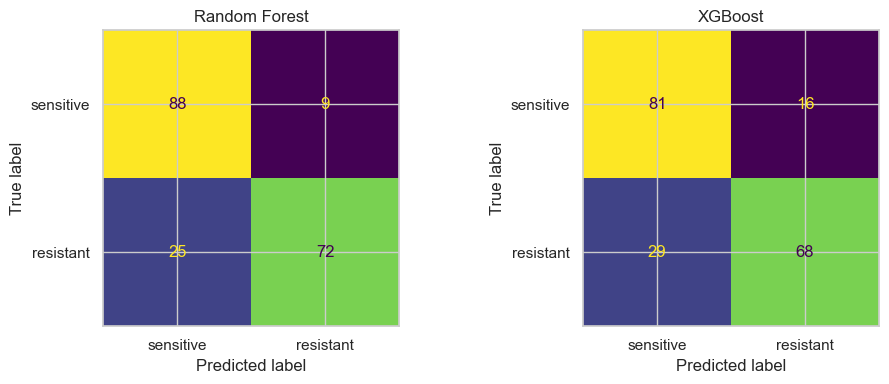

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, rfm_pred),
                        display_labels=['sensitive', 'resistant']).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(confusion_matrix(y_test, xgb_pred),
                        display_labels=['sensitive', 'resistant']).plot(ax=axes[1], colorbar=False)
axes[1].set_title("XGBoost")

plt.tight_layout()
plt.show()

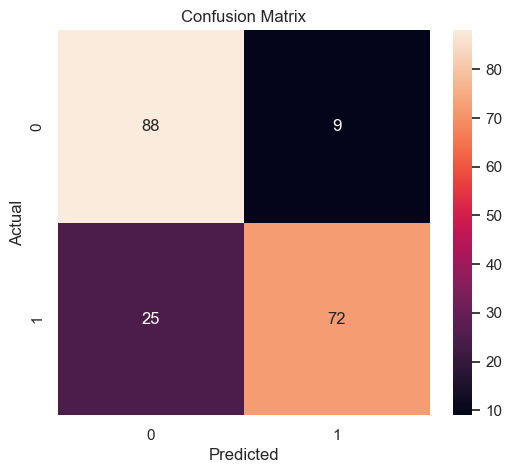

[[88  9]
 [25 72]]


In [141]:
cm = confusion_matrix(y_test, rfm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(cm)

#### XG Boost

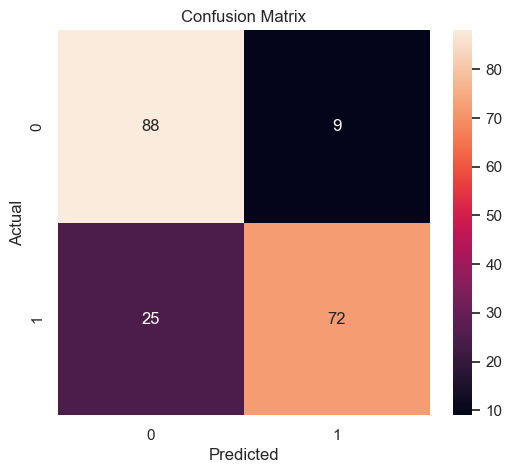

[[81 16]
 [29 68]]


In [146]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(cm_xgb)

### Step 11: ROC Curve

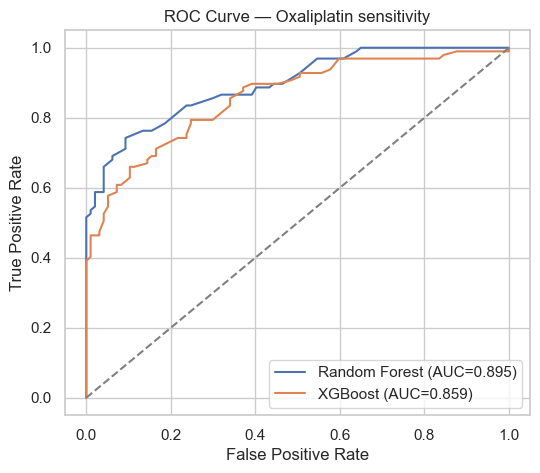

In [147]:
rf_prob = rfm.predict_proba(X_test_scaled)[:, 1]
xgb_prob = xgb_clf.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

auc_rf = roc_auc_score(y_test, rf_prob)
auc_xgb = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {DRUG_OF_INTEREST} sensitivity")
plt.legend()
plt.show()

#### Random Forest

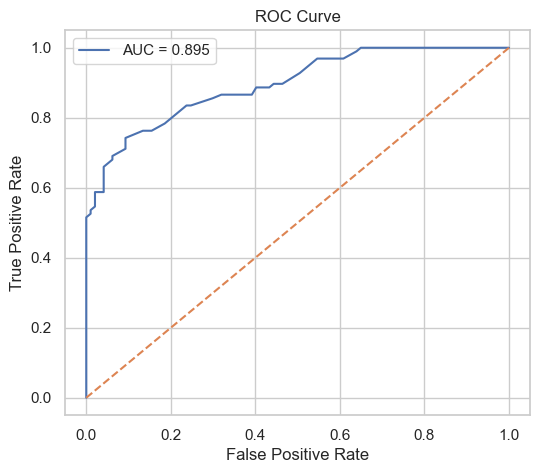

AUC Score: 0.8952598575831651


In [153]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities
y_prob = rfm.predict_proba(X_test_scaled)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:", auc_score)

#### XGBoost Model - ROC

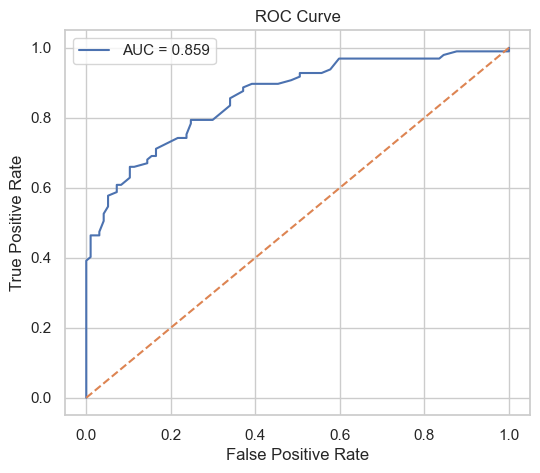

AUC Score: 0.8588053990859815


In [154]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities
x_prob = xgb_clf.predict_proba(X_test_scaled)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, x_prob)

# AUC score
auc_score = roc_auc_score(y_test, x_prob)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:", auc_score)

### Feature Importance

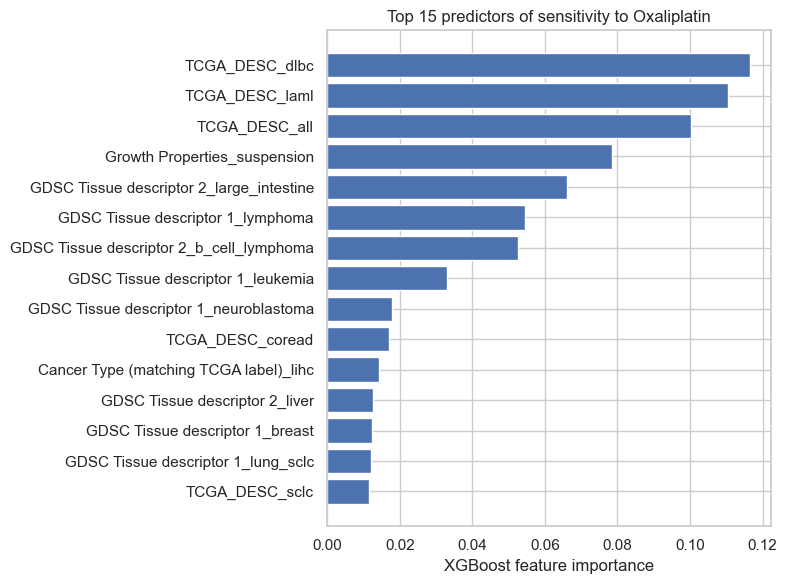

In [152]:
importances = xgb_clf.feature_importances_
feat_names = X.columns

top_n = 15
top_idx = np.argsort(importances)[-top_n:]

plt.figure(figsize=(8,6))
plt.barh(feat_names[top_idx], importances[top_idx])
plt.xlabel("XGBoost feature importance")
plt.title(f"Top {top_n} predictors of sensitivity to {DRUG_OF_INTEREST}")
plt.tight_layout()
plt.show()